# Triage Brief: Prioritizing the 2023 Portfolio

800 CVEs affecting our infrastructure. Goal: identify immediate threats and prioritize remediation.

This is a **tactical** triage notebook -- it surfaces individual CVEs for action. For portfolio-level executive metrics, see notebook 09.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vulnstate import CVDArray, CVDEvent

Data loading uses `orjson` internally via `import_nvd(path)`. The EPSS and KEV enrichment layers attach exploitation probability scores and federal mandate flags to matching CVEs by ID.

In [2]:
arr = CVDArray()
arr.import_nvd("sample_nvdcve_2023.json")
arr.import_epss("sample_epss.csv")
arr.import_kev("sample_kev.csv")
arr.import_csv("sample_deployed.csv", cve_column="cve_id", event=CVDEvent.D, timestamp_column="deployed_date")
result = arr.analysis

# Prepare working DataFrame
df = arr.to_dataframe(include_events=True)
cvss = arr.cvss_scores
severity = np.where(cvss >= 9.0, "CRITICAL",
           np.where(cvss >= 7.0, "HIGH",
           np.where(cvss >= 4.0, "MEDIUM",
           np.where(cvss >= 0.1, "LOW", "NONE"))))
df["severity"] = severity

total = len(arr)
kev_count = int(arr.kev.sum())
zd_count = int(result.is_zero_day.sum())
patch_rate = arr.has_event_occurred(CVDEvent.F).sum() / total * 100
print(f"Portfolio: {total} CVEs | KEV mandates: {kev_count} | "
      f"Zero-days: {zd_count} | Patch rate: {patch_rate:.0f}%")

Portfolio: 800 CVEs | KEV mandates: 37 | Zero-days: 19 | Patch rate: 25%


Critical Exposure: Unpatched + Threatened

The highest-urgency subset: vulnerabilities with **no fix available** (`~is_fix`) AND an active threat (public exploit X or observed attacks A). These require immediate compensating controls or vendor escalation.

In [3]:
# Vectorized boolean mask operations -- no Python loops
is_fix = arr.has_event_occurred(CVDEvent.F)
is_weapon = arr.has_event_occurred(CVDEvent.X)
is_attack = arr.has_event_occurred(CVDEvent.A)
critical_mask = (~is_fix) & (is_weapon | is_attack)

critical_df = df[critical_mask].copy()
critical_df = critical_df[["cve_id", "cvss_score", "epss", "severity", "kev", "state"]].copy()
critical_df = critical_df.sort_values("epss", ascending=False)

print(f"{len(critical_df)} vulnerabilities with no fix AND active threat")
critical_df.head(20)

299 vulnerabilities with no fix AND active threat


,cve_id,cvss_score,epss,severity,kev,state
20,CVE-2023-27350,9.8,0.96921,CRITICAL,True,VfdPXA
28,CVE-2023-28771,NaN,0.91122,NONE,True,VfdPXA
36,CVE-2023-34362,9.8,0.80771,CRITICAL,True,VfdPXA
12,CVE-2023-22952,8.8,0.64202,HIGH,True,VfdPXA
26,CVE-2023-28432,7.5,0.42964,HIGH,True,VfdPXA
18,CVE-2023-26083,3.3,0.06150,LOW,True,VfdPxA
21,CVE-2023-27997,9.8,0.05748,CRITICAL,True,VfdPxA
30,CVE-2023-29492,9.8,0.03392,CRITICAL,True,VfdPxA
642,CVE-2023-0630,8.8,0.02466,HIGH,False,VfdPXa
35,CVE-2023-33010,9.8,0.02075,CRITICAL,True,VfdPxA


Zero-Days in the Portfolio

A zero-day is a vulnerability exploited or attacked before the vendor is aware (X or A before V). The scatter reveals which zero-days combine high EPSS (likely to be exploited again) with high CVSS (severe impact).

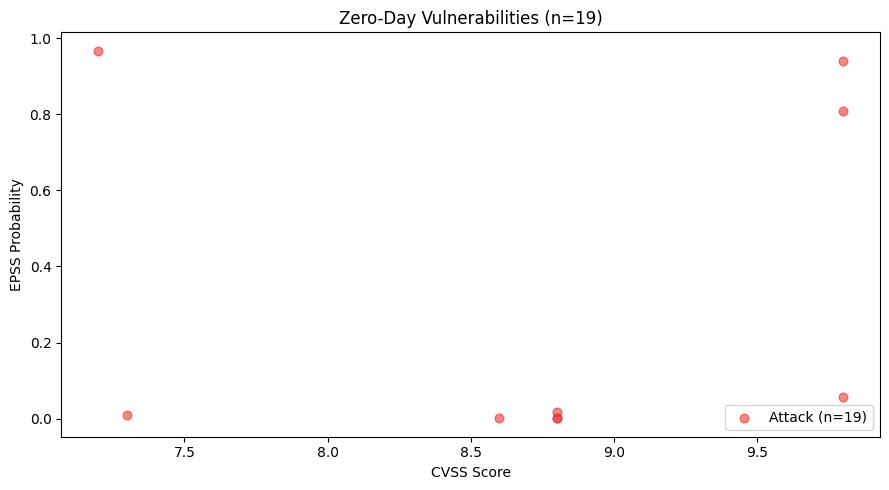


Top 10 Zero-Days by EPSS:


,cve_id,cvss_score,epss,kev,zd_type
1,CVE-2023-0669,7.2,0.96695,True,Attack
14,CVE-2023-23397,9.8,0.93943,True,Attack
19,CVE-2023-26360,NaN,0.87425,True,Attack
36,CVE-2023-34362,9.8,0.80771,True,Attack
10,CVE-2023-21823,NaN,0.77497,True,Attack
25,CVE-2023-28252,NaN,0.23733,True,Attack
21,CVE-2023-27997,9.8,0.05748,True,Attack
2,CVE-2023-1389,8.8,0.01664,True,Attack
16,CVE-2023-24880,NaN,0.01075,True,Attack
9,CVE-2023-21715,7.3,0.00972,True,Attack


In [4]:
zd_mask = result.is_zero_day
zd_df = df[zd_mask].copy()

# Classify zero-day type
zd_type = np.where(result.is_zero_day_attack[zd_mask] & result.is_zero_day_exploit[zd_mask], "Both",
           np.where(result.is_zero_day_attack[zd_mask], "Attack", "Exploit"))
zd_df["zd_type"] = zd_type

fig, ax = plt.subplots(figsize=(9, 5))
colors_map = {"Exploit": "#f57c00", "Attack": "#e53935", "Both": "#6a1b9a"}
for ztype, color in colors_map.items():
    subset = zd_df[zd_df["zd_type"] == ztype]
    if len(subset) > 0:
        ax.scatter(subset["cvss_score"], subset["epss"], alpha=0.6, s=40,
                  color=color, label=f"{ztype} (n={len(subset)})")

ax.set_xlabel("CVSS Score")
ax.set_ylabel("EPSS Probability")
ax.set_title(f"Zero-Day Vulnerabilities (n={len(zd_df)})")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 Zero-Days by EPSS:")
zd_df[["cve_id", "cvss_score", "epss", "kev", "zd_type"]].sort_values("epss", ascending=False).head(10)

CISA KEV Compliance

KEV entries carry **mandatory** remediation deadlines. The left panel shows fix status; the right shows how long unpatched KEV vulnerabilities have been disclosed -- each day overdue increases compliance risk.

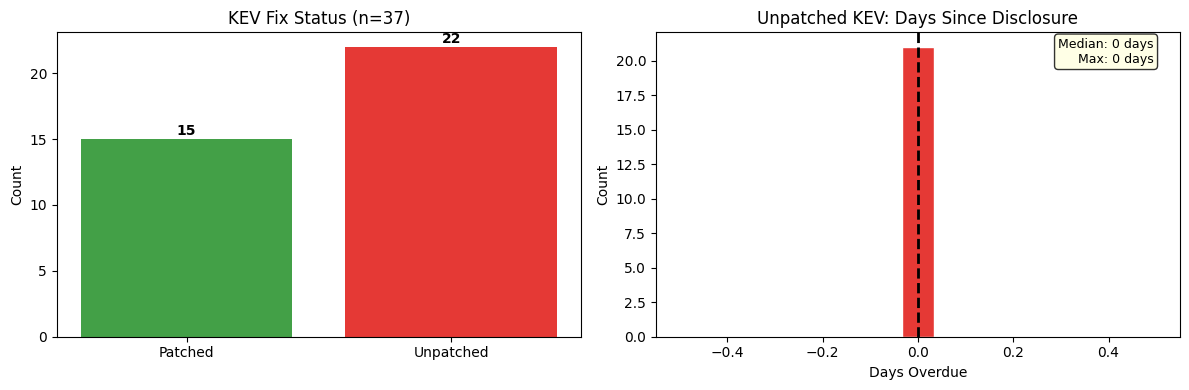

In [5]:
kev_mask = arr.kev
kev_fixed = int((kev_mask & is_fix).sum())
kev_unpatched = kev_count - kev_fixed

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Fix status
bars = ax1.bar(["Patched", "Unpatched"], [kev_fixed, kev_unpatched],
              color=["#43a047", "#e53935"])
for bar, val in zip(bars, [kev_fixed, kev_unpatched]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha="center", fontweight="bold")
ax1.set_title(f"KEV Fix Status (n={kev_count})")
ax1.set_ylabel("Count")

# Age of unpatched KEV (days since public disclosure)
kev_unfixed_mask = kev_mask & ~is_fix
kev_age = result.disclosure_window_days[kev_unfixed_mask]
valid_age = kev_age[~np.isnan(kev_age) & (kev_age >= 0)]
if len(valid_age) > 0:
    ax2.hist(valid_age, bins=15, color="#e53935", edgecolor="white")
    median_age = np.median(valid_age)
    ax2.axvline(median_age, color="black", linestyle="--", linewidth=2)
    ax2.text(0.95, 0.9, f"Median: {median_age:.0f} days\nMax: {valid_age.max():.0f} days",
            transform=ax2.transAxes, ha="right", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
ax2.set_title("Unpatched KEV: Days Since Disclosure")
ax2.set_xlabel("Days Overdue")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

Priority Queue

Composite priority score computed entirely with vectorized numpy operations (no Python loops). Weights: KEV (+100), zero-day (+50), high EPSS >0.5 (+30), critical CVSS >=9.0 (+20). The top-20 are the immediate action list.

In [6]:
kev_score = arr.kev.astype(np.float32) * 100
zd_score = result.is_zero_day.astype(np.float32) * 50
high_epss_score = (arr.epss > 0.5).astype(np.float32) * 30
critical_cvss_score = (cvss >= 9.0).astype(np.float32) * 20

priority = kev_score + zd_score + high_epss_score + critical_cvss_score
df["priority"] = priority

priority_df = df[priority > 0].copy()
priority_df = priority_df.sort_values("priority", ascending=False)

print(f"{len(priority_df)} vulnerabilities with priority score > 0")
priority_df[["cve_id", "priority", "cvss_score", "epss", "severity", "kev", "state"]].head(20)

114 vulnerabilities with priority score > 0


,cve_id,priority,cvss_score,epss,severity,kev,state
14,CVE-2023-23397,200.0,9.8,0.93943,CRITICAL,True,VFDPxA
36,CVE-2023-34362,200.0,9.8,0.80771,CRITICAL,True,VfdPXA
10,CVE-2023-21823,180.0,NaN,0.77497,NONE,True,VFDPxA
1,CVE-2023-0669,180.0,7.2,0.96695,HIGH,True,VFDPXA
19,CVE-2023-26360,180.0,NaN,0.87425,NONE,True,VFdPXA
21,CVE-2023-27997,170.0,9.8,0.05748,CRITICAL,True,VfdPxA
13,CVE-2023-23376,150.0,NaN,0.00572,NONE,True,VFDPxA
16,CVE-2023-24880,150.0,NaN,0.01075,NONE,True,VFdPxA
2,CVE-2023-1389,150.0,8.8,0.01664,HIGH,True,VfdPXA
4,CVE-2023-20887,150.0,9.8,0.82708,CRITICAL,True,VFdPXA


Remediation Pipeline

The VFD progression shows how many vulnerabilities are at each fix stage. The **fix gap** (V-only) and **deploy gap** (V+F but no D) represent actionable backlogs.

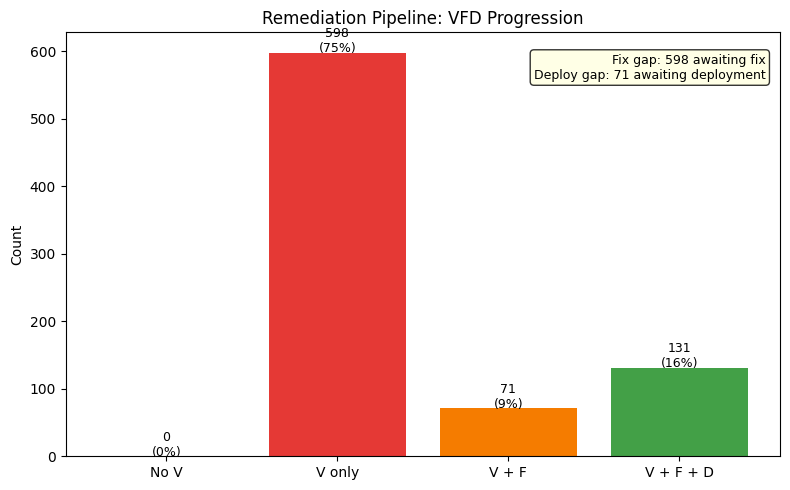

In [7]:
has_v = arr.has_event_occurred(CVDEvent.V)
has_f = arr.has_event_occurred(CVDEvent.F)
has_d = arr.has_event_occurred(CVDEvent.D)

v_only = int((has_v & ~has_f & ~has_d).sum())
v_f = int((has_v & has_f & ~has_d).sum())
v_f_d = int((has_v & has_f & has_d).sum())
none_stage = int((~has_v).sum())

stages = ["No V", "V only", "V + F", "V + F + D"]
stage_counts = [none_stage, v_only, v_f, v_f_d]
colors = ["#90a4ae", "#e53935", "#f57c00", "#43a047"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stages, stage_counts, color=colors)
for bar, count in zip(bars, stage_counts):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{count}\n({pct:.0f}%)", ha="center", fontsize=9)

ax.set_title("Remediation Pipeline: VFD Progression")
ax.set_ylabel("Count")

ax.text(0.98, 0.95, f"Fix gap: {v_only} awaiting fix\nDeploy gap: {v_f} awaiting deployment",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

Coordination Quality

The desiderata score (0 to 1) captures how well each CVE's disclosure was coordinated -- whether the vendor learned before the public, whether fixes preceded exploits, etc. The box plot compares KEV vs non-KEV to see if exploited vulnerabilities had worse coordination.

C:\Users\corifeo\AppData\Local\Temp\ipykernel_28848\3066106620.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True)


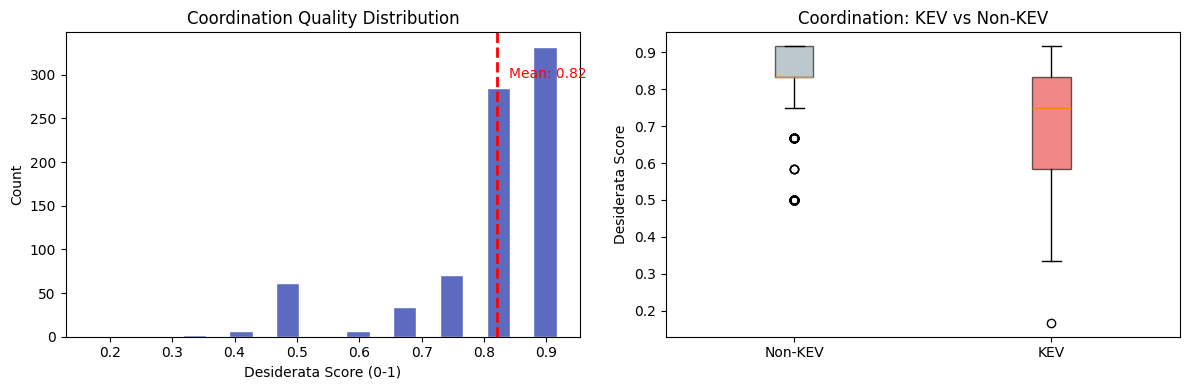

In [8]:
scores = result.desiderata_score
valid_scores = scores[~np.isnan(scores)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax1.hist(valid_scores, bins=20, color="#5c6bc0", edgecolor="white")
mean_s = valid_scores.mean()
ax1.axvline(mean_s, color="red", linestyle="--", linewidth=2)
ax1.text(mean_s + 0.02, ax1.get_ylim()[1] * 0.85, f"Mean: {mean_s:.2f}",
         color="red", fontsize=10)
ax1.set_xlabel("Desiderata Score (0-1)")
ax1.set_ylabel("Count")
ax1.set_title("Coordination Quality Distribution")

# Box plot: KEV vs non-KEV
kev_scores = scores[arr.kev & ~np.isnan(scores)]
non_kev_scores = scores[~arr.kev & ~np.isnan(scores)]

box_data = [d for d in [non_kev_scores, kev_scores] if len(d) > 0]
box_labels = [l for l, d in zip(["Non-KEV", "KEV"], [non_kev_scores, kev_scores]) if len(d) > 0]
bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True)
box_colors = ["#90a4ae", "#e53935"][:len(box_data)]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_ylabel("Desiderata Score")
ax2.set_title("Coordination: KEV vs Non-KEV")

plt.tight_layout()
plt.show()

## Recommendations

- **Immediate:** Remediate all unpatched KEV entries -- these are federal compliance mandates with enforceable deadlines
- **Urgent:** Prioritize the critical-exposure set (no fix + active threat) for vendor escalation or compensating controls
- **Operational:** Close the deployment gap -- vulnerabilities with fixes available but not deployed represent preventable risk
- **Strategic:** Invest in coordination quality improvement; low desiderata scores indicate systemic disclosure process failures